# Dataset Generation Comparison

This notebook compares dataset generation across backends and optimization settings for:
- the SRV task
- the unitary-compilation task

It runs the generator programmatically, measures runtime, computes the retained unique-sample ratio from saved dataset size vs requested samples, and saves a reproducible artifact bundle under `artifacts/evaluations/...`.


In [9]:
import os
os.chdir('..')

from pathlib import Path
import time

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

from shared.bootstrap import setup_notebook_paths

PROJECT_ROOT = setup_notebook_paths()

from notebooks.shared.evaluation_artifacts import (
    make_artifact_dir,
    save_dataframe,
    save_figure,
    save_json,
    save_pickle,
    save_text,
)
from quantum_diffusion.data.dataset import DatasetGenerator
from my_genQC.utils.misc_utils import infer_torch_device


In [13]:
# -- Edit only this cell -------------------------------------------------------

RUN_NAME = "backend_comparison"
ARTIFACT_SUBDIR = "srv_dataset_backend_comparison"
ARTIFACT_DIR = make_artifact_dir(PROJECT_ROOT, ARTIFACT_SUBDIR, RUN_NAME)

DEVICE = str(infer_torch_device())
OVERWRITE_EXISTING = True

SRV_CASES = [
    {
        "task": "srv",
        "label": "qiskit_optimized_10k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "qiskit",
        "optimized": True,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "qiskit_optimized_10k"),
    },
    {
        "task": "srv",
        "label": "qiskit_optimized_100k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "qiskit",
        "optimized": True,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "qiskit_optimized_100k"),
    },
    {
        "task": "srv",
        "label": "qiskit_not_optimized_10k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "qiskit",
        "optimized": False,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "qiskit_not_optimized_10k"),
    },
    {
        "task": "srv",
        "label": "qiskit_not_optimized_100k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "qiskit",
        "optimized": False,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "qiskit_not_optimized_100k"),
    },
    {
        "task": "srv",
        "label": "quditkit_optimized_10k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "quditkit",
        "optimized": True,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "quditkit_optimized_10k"),
    },
    {
        "task": "srv",
        "label": "quditkit_optimized_100k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "quditkit",
        "optimized": True,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "quditkit_optimized_100k"),
    },
    {
        "task": "srv",
        "label": "quditkit_not_optimized_10k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "quditkit",
        "optimized": False,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "quditkit_not_optimized_10k"),
    },
    {
        "task": "srv",
        "label": "quditkit_not_optimized_100k",
        "gate_set": ["h", "cx"],
        "num_qubits": 5,
        "min_gates": 4,
        "max_gates": 20,
        "condition_type": "SRV",
        "backbone": "quditkit",
        "optimized": False,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "srv" / "quditkit_not_optimized_100k"),
    },
]

UNITARY_CASES = [
    {
        "task": "unitary",
        "label": "qiskit_optimized_10k",
        "gate_set": ["h", "cx", "z", "x", "ccx", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "qiskit",
        "optimized": True,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "qiskit_optimized_10k"),
    },
    {
        "task": "unitary",
        "label": "qiskit_optimized_100k",
        "gate_set": ["h", "cx", "z", "x", "ccx", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "qiskit",
        "optimized": True,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "qiskit_optimized_100k"),
    },
    {
        "task": "unitary",
        "label": "qiskit_not_optimized_10k",
        "gate_set": ["h", "cx", "z", "x", "ccx", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "qiskit",
        "optimized": False,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "qiskit_not_optimized_10k"),
    },
    {
        "task": "unitary",
        "label": "qiskit_not_optimized_100k",
        "gate_set": ["h", "cx", "z", "x", "ccx", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "qiskit",
        "optimized": False,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "qiskit_not_optimized_100k"),
    },
    {
        "task": "unitary",
        "label": "quditkit_optimized_10k",
        "gate_set": ["h", "cx", "z", "x", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "quditkit",
        "optimized": True,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "quditkit_optimized_10k"),
    },
    {
        "task": "unitary",
        "label": "quditkit_optimized_100k",
        "gate_set": ["h", "cx", "z", "x", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "quditkit",
        "optimized": True,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "quditkit_optimized_100k"),
    },
    {
        "task": "unitary",
        "label": "quditkit_not_optimized_10k",
        "gate_set": ["h", "cx", "z", "x", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "quditkit",
        "optimized": False,
        "num_samples": 10_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "quditkit_not_optimized_10k"),
    },
    {
        "task": "unitary",
        "label": "quditkit_not_optimized_100k",
        "gate_set": ["h", "cx", "z", "x", "swap"],
        "num_qubits": 3,
        "min_gates": 2,
        "max_gates": 12,
        "condition_type": "UNITARY",
        "backbone": "quditkit",
        "optimized": False,
        "num_samples": 100_000,
        "output_path": str(PROJECT_ROOT / "artifacts" / "datasets" / "tmp_backend_comparison" / "unitary" / "quditkit_not_optimized_100k"),
    },
]

CASES = SRV_CASES + UNITARY_CASES
print(f"Artifact dir: {ARTIFACT_DIR}")
print(f"Device: {DEVICE}")
print(f"Cases: {len(CASES)}")


[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
Artifact dir: /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/srv_dataset_backend_comparison/backend_comparison
Device: cuda
Cases: 16


In [14]:
def resolve_saved_dataset_dir(case, generation_results):
    if len(generation_results) != 1:
        raise ValueError(
            f"Expected exactly one generated condition for {case['label']}, got keys: {list(generation_results)}"
        )

    metadata = next(iter(generation_results.values()))
    output_path = Path(metadata["output_path"])

    if (output_path / "config.yaml").exists():
        return output_path, metadata

    raise FileNotFoundError(f"Expected saved dataset under {output_path}")


def read_dataset_config(dataset_dir):
    with (dataset_dir / "config.yaml").open("r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def summarize_case(case, generation_results, elapsed_seconds):
    dataset_dir, metadata = resolve_saved_dataset_dir(case, generation_results)
    dataset_cfg = read_dataset_config(dataset_dir)
    params = dataset_cfg.get("params", {})
    unique_samples = int(metadata["num_samples"])
    requested_samples = int(case["num_samples"])
    unique_ratio = unique_samples / requested_samples if requested_samples else float("nan")

    return {
        "task": case["task"],
        "label": case["label"],
        "backbone": case["backbone"],
        "optimized": bool(case["optimized"]),
        "requested_samples": requested_samples,
        "unique_samples": unique_samples,
        "unique_ratio": unique_ratio,
        "elapsed_seconds": elapsed_seconds,
        "output_path": str(dataset_dir),
        "gate_set": list(case["gate_set"]),
        "num_qubits": int(case["num_qubits"]),
        "min_gates": int(case["min_gates"]),
        "max_gates": int(case["max_gates"]),
        "pad_constant": params.get("pad_constant"),
        "comment": dataset_cfg.get("comment"),
    }


def run_case(case, generator):
    output_path = Path(case["output_path"])
    if output_path.exists() and not OVERWRITE_EXISTING:
        raise FileExistsError(f"Refusing to overwrite existing output: {output_path}")

    start = time.perf_counter()
    generation_results = generator.generate_dataset(
        gate_set=case["gate_set"],
        num_qubits=case["num_qubits"],
        num_samples=case["num_samples"],
        min_gates=case["min_gates"],
        max_gates=case["max_gates"],
        backbone=case["backbone"],
        condition_type=case["condition_type"],
        optimized=case["optimized"],
        output_path=case["output_path"],
        n_jobs=4,
    )
    elapsed = time.perf_counter() - start
    return summarize_case(case, generation_results, elapsed)


generator = DatasetGenerator(device=DEVICE)
rows = []
for case in CASES:
    print(f"Running {case['task']} | {case['label']}")
    rows.append(run_case(case, generator))

results_df = pd.DataFrame(rows).sort_values(["task", "backbone", "optimized", "requested_samples"]).reset_index(drop=True)
summary_tables = {
    task: df.drop(columns=["output_path", "gate_set", "comment"]).copy()
    for task, df in results_df.groupby("task", sort=False)
}

save_dataframe(results_df, ARTIFACT_DIR / "all_runs.csv", index=False)
for task, df in summary_tables.items():
    save_dataframe(df, ARTIFACT_DIR / f"{task}_summary.csv", index=False)
save_pickle(rows, ARTIFACT_DIR / "results.pkl")
save_json({"cases": CASES, "device": DEVICE, "results": rows}, ARTIFACT_DIR / "run_config_and_results.json")
save_text(f"Saved dataset generation comparison artifacts to {ARTIFACT_DIR}\n", ARTIFACT_DIR / "README.txt")

for task, df in summary_tables.items():
    print(f"\n## {task.upper()} summary")
    display(df)


Running srv | qiskit_optimized_10k
2026-04-13 17:41:15 - quantum_diffusion.data.dataset - INFO - Generating dataset with 10000 samples, 5 qubits
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...
2026-04-13 17:41:15 - quantum_diffusion.data.dataset - INFO - Starting circuit generation for SRV...
[INFO]: Generated 9976 valid circuits.
[INFO]: After filtering unique circuits: 9808.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/srv/qiskit_optimized_10k/dataset/ds_x.safetensors`.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/srv/qiskit_optimized_10k/dataset/ds_y.safetensors`.
2026-04-13 17:41:32 - quantum_diffusion.data.dataset - INFO - SRV dataset saved to /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_bac

  0%|          | 0/1 [00:00<?, ?it/s]

 - balance_tensor_dataset, njobs=1, number of samples=8623
 - uniquify_tensor_dataset, number of samples now 8623
 - balancing


  0%|          | 0/57 [00:00<?, ?it/s]

 - dataset size after balancing 8623
[INFO]: allocate memory for U (8623, 2, 8, 8) on cpu approx. 0.004 GB
Split: Train 8622 - Test 1 

[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/qiskit_optimized_10k/dataset/ds_x.safetensors`.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/qiskit_optimized_10k/dataset/ds_y.safetensors`.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/qiskit_optimized_10k/dataset/ds_U.safetensors`.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/qiskit_optimized_10k/dataset/ds_z.safetensors`.
2026-04-13 17:49:32 - quantum_diffusion.data.dataset - INFO - UNITARY dataset saved to /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/qiskit_opti

...

  0%|          | 0/26 [00:00<?, ?it/s]

 - dataset size after balancing 86534
[INFO]: allocate memory for U (86534, 2, 8, 8) on cpu approx. 0.041 GB
Split: Train 86533 - Test 1 

[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/quditkit_not_optimized_100k/dataset/ds_x.safetensors`.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/quditkit_not_optimized_100k/dataset/ds_y.safetensors`.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/quditkit_not_optimized_100k/dataset/ds_U.safetensors`.
[INFO]: Saving tensor to `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend_comparison/unitary/quditkit_not_optimized_100k/dataset/ds_z.safetensors`.
2026-04-13 17:54:49 - quantum_diffusion.data.dataset - INFO - UNITARY dataset saved to /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/tmp_backend

,task,label,backbone,optimized,requested_samples,unique_samples,unique_ratio,elapsed_seconds,num_qubits,min_gates,max_gates,pad_constant
0,srv,qiskit_not_optimized_10k,qiskit,False,10000,9983,0.99830,10.830137,5,4,20,NaN
1,srv,qiskit_not_optimized_100k,qiskit,False,100000,99682,0.99682,102.622909,5,4,20,NaN
2,srv,qiskit_optimized_10k,qiskit,True,10000,9808,0.98080,16.868596,5,4,20,NaN
3,srv,qiskit_optimized_100k,qiskit,True,100000,94403,0.94403,156.204033,5,4,20,NaN
4,srv,quditkit_not_optimized_10k,quditkit,False,10000,9979,0.99790,4.437799,5,4,20,NaN
5,srv,quditkit_not_optimized_100k,quditkit,False,100000,99705,0.99705,41.720198,5,4,20,NaN
6,srv,quditkit_optimized_10k,quditkit,True,10000,9982,0.99820,15.179807,5,4,20,NaN
7,srv,quditkit_optimized_100k,quditkit,True,100000,99711,0.99711,137.607202,5,4,20,NaN



## UNITARY summary


,task,label,backbone,optimized,requested_samples,unique_samples,unique_ratio,elapsed_seconds,num_qubits,min_gates,max_gates,pad_constant
8,unitary,qiskit_not_optimized_10k,qiskit,False,10000,9353,0.93530,5.092132,3,2,12,7.0
9,unitary,qiskit_not_optimized_100k,qiskit,False,100000,86825,0.86825,44.570310,3,2,12,7.0
10,unitary,qiskit_optimized_10k,qiskit,True,10000,8623,0.86230,11.501966,3,2,12,7.0
11,unitary,qiskit_optimized_100k,qiskit,True,100000,75917,0.75917,102.866602,3,2,12,7.0
12,unitary,quditkit_not_optimized_10k,quditkit,False,10000,9322,0.93220,4.069372,3,2,12,6.0
13,unitary,quditkit_not_optimized_100k,quditkit,False,100000,86534,0.86534,34.069420,3,2,12,6.0
14,unitary,quditkit_optimized_10k,quditkit,True,10000,9364,0.93640,12.555551,3,2,12,6.0
15,unitary,quditkit_optimized_100k,quditkit,True,100000,86452,0.86452,113.493559,3,2,12,6.0


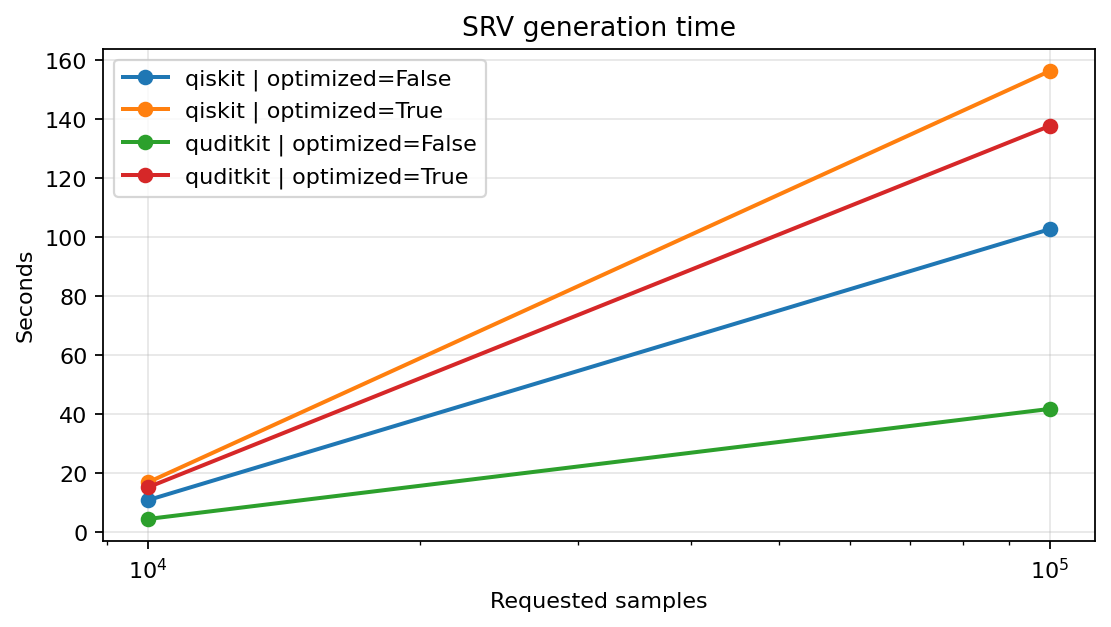

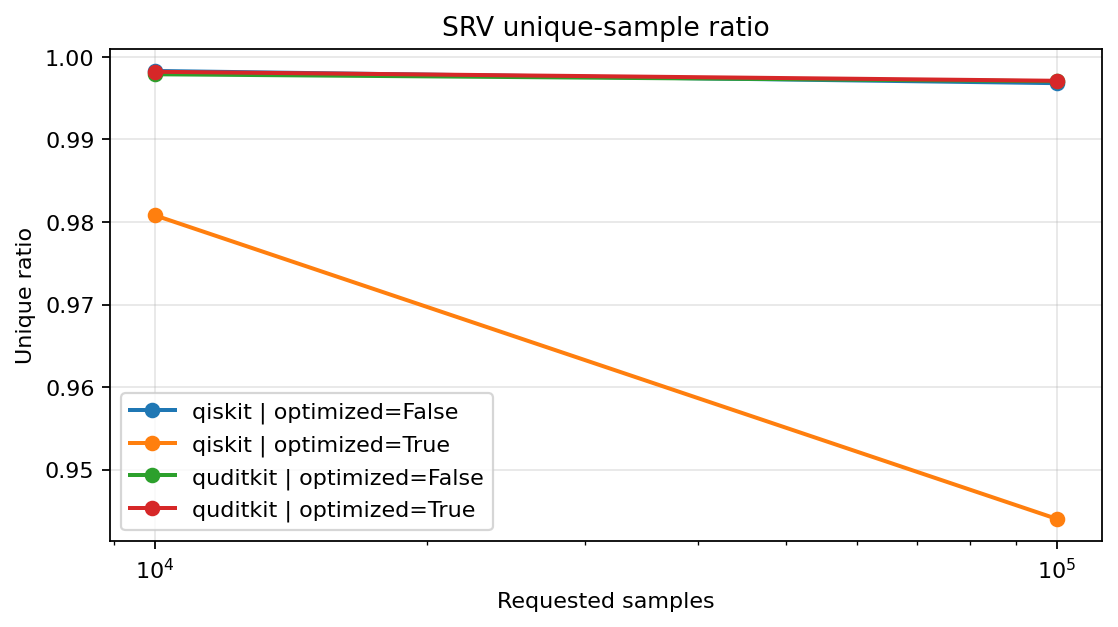

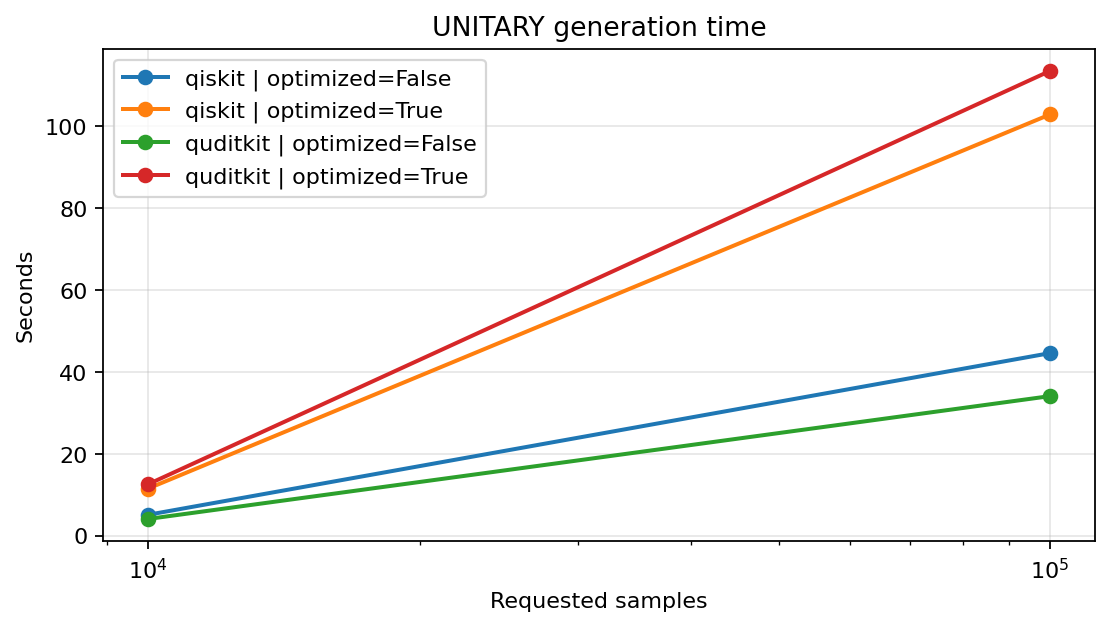

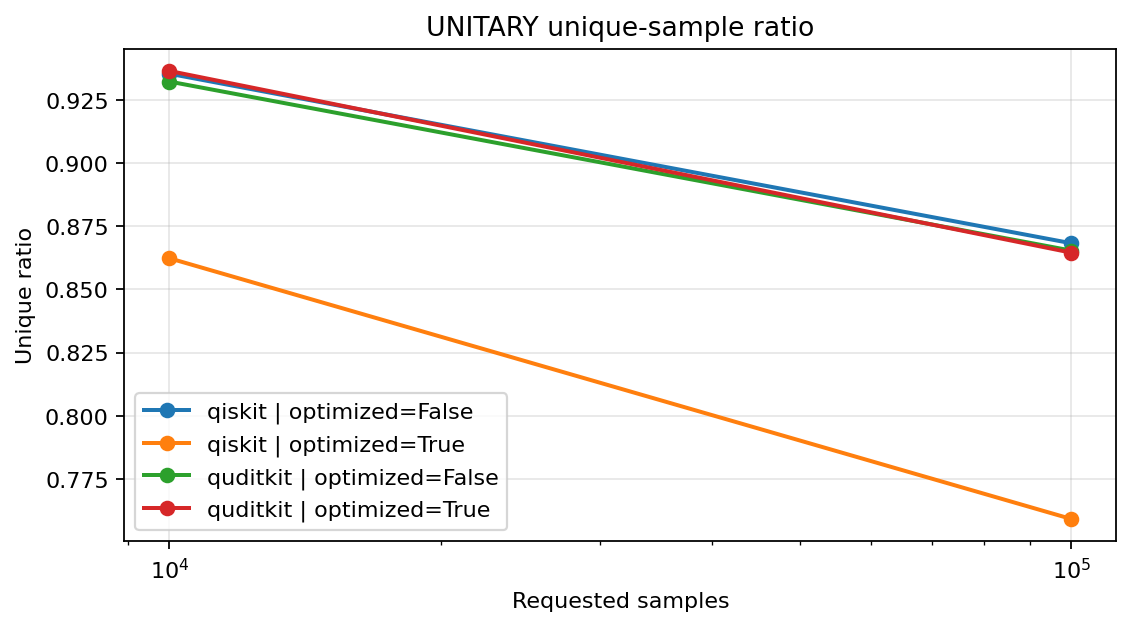

In [15]:
def plot_metric(task_df, metric, ylabel, title):
    fig, ax = plt.subplots(figsize=(8, 4), dpi=160)
    for (backbone, optimized), subdf in task_df.groupby(["backbone", "optimized"], sort=False):
        subdf = subdf.sort_values("requested_samples")
        label = f"{backbone} | optimized={optimized}"
        ax.plot(subdf["requested_samples"], subdf[metric], marker="o", linewidth=1.8, label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Requested samples")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    return fig

for task, df in results_df.groupby("task", sort=False):
    fig_time = plot_metric(df, "elapsed_seconds", "Seconds", f"{task.upper()} generation time")
    save_figure(fig_time, ARTIFACT_DIR / f"{task}_generation_time.png")
    plt.show()

    fig_unique = plot_metric(df, "unique_ratio", "Unique ratio", f"{task.upper()} unique-sample ratio")
    save_figure(fig_unique, ARTIFACT_DIR / f"{task}_unique_ratio.png")
    plt.show()


In [16]:
results_df


,task,label,backbone,optimized,requested_samples,unique_samples,unique_ratio,elapsed_seconds,output_path,gate_set,num_qubits,min_gates,max_gates,pad_constant,comment
0,srv,qiskit_not_optimized_10k,qiskit,False,10000,9983,0.99830,10.830137,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
1,srv,qiskit_not_optimized_100k,qiskit,False,100000,99682,0.99682,102.622909,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
2,srv,qiskit_optimized_10k,qiskit,True,10000,9808,0.98080,16.868596,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
3,srv,qiskit_optimized_100k,qiskit,True,100000,94403,0.94403,156.204033,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
4,srv,quditkit_not_optimized_10k,quditkit,False,10000,9979,0.99790,4.437799,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
5,srv,quditkit_not_optimized_100k,quditkit,False,100000,99705,0.99705,41.720198,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
6,srv,quditkit_optimized_10k,quditkit,True,10000,9982,0.99820,15.179807,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
7,srv,quditkit_optimized_100k,quditkit,True,100000,99711,0.99711,137.607202,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx]",5,4,20,NaN,"generation_gate_set=['h', 'cx']; token_gate_se..."
8,unitary,qiskit_not_optimized_10k,qiskit,False,10000,9353,0.93530,5.092132,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx, z, x, ccx, swap]",3,2,12,7.0,"generation_gate_set=['h', 'cx', 'z', 'x', 'ccx..."
9,unitary,qiskit_not_optimized_100k,qiskit,False,100000,86825,0.86825,44.570310,/home/a-ldungl/projects/qcircuit-generation/ar...,"[h, cx, z, x, ccx, swap]",3,2,12,7.0,"generation_gate_set=['h', 'cx', 'z', 'x', 'ccx..."
